<a href="https://www.kaggle.com/code/lalit7881/netflix-movies-and-series-eda-100?scriptVersionId=339287128" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/debayank2024/netflix-movies-and-series/netflix_titles.csv


In [2]:
plt.switch_backend('Agg')  # If only plt module is used
get_ipython().run_line_magic('matplotlib', 'inline')

import seaborn as sns
sns.set(style='whitegrid')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# Display all columns if needed
pd.set_option('display.max_columns', None)

## Loading dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/debayank2024/netflix-movies-and-series/netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [11]:
df.nunique()

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

## EDA

In [12]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Convert date_added safely
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce",
    format="mixed"
)

# Extract movie duration in minutes
movie_mask = df["type"] == "Movie"
df.loc[movie_mask, "movie_duration"] = (
    df.loc[movie_mask, "duration"]
      .str.extract(r'(\d+)')[0]
      .astype(float)
)

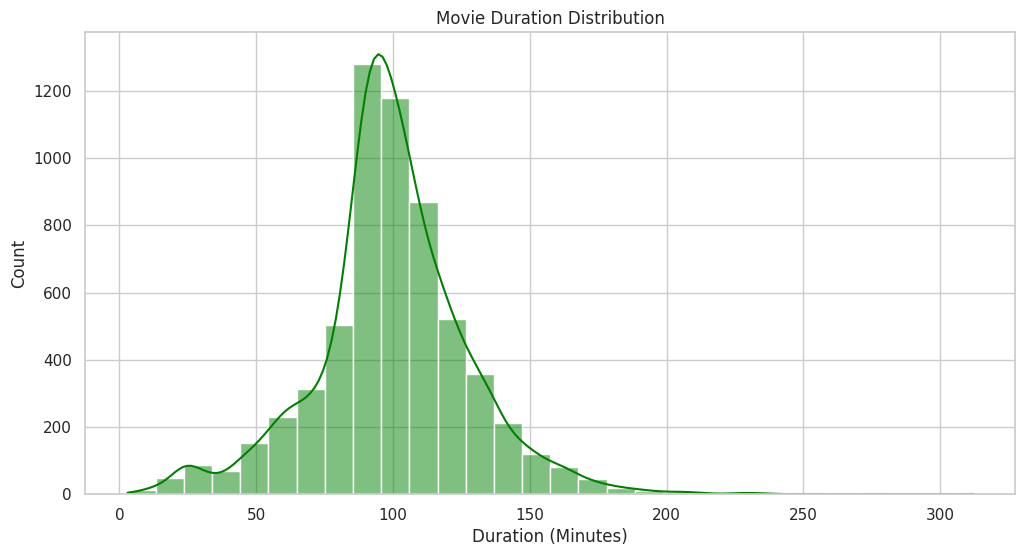

In [13]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["movie_duration"].dropna(),
    bins=30,
    kde=True,
    color="green"
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Count")

plt.show()

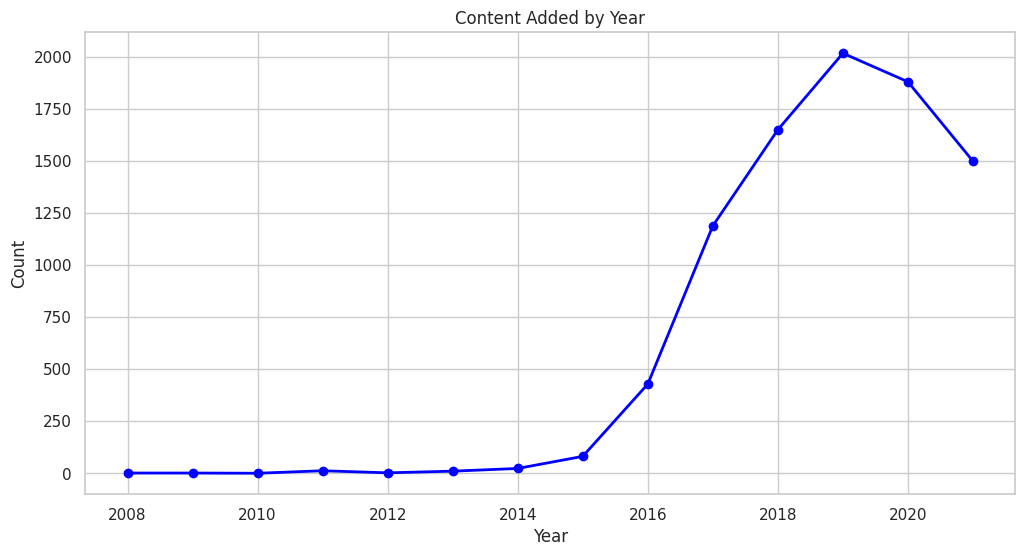

In [14]:
# ==========================================================
# Date Added Analysis
# ==========================================================

added = (
    df["date_added"]
      .dt.year
      .dropna()
      .astype(int)
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    added.index,
    added.values,
    marker="o",
    linewidth=2,
    color="blue"
)

plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)

plt.show()

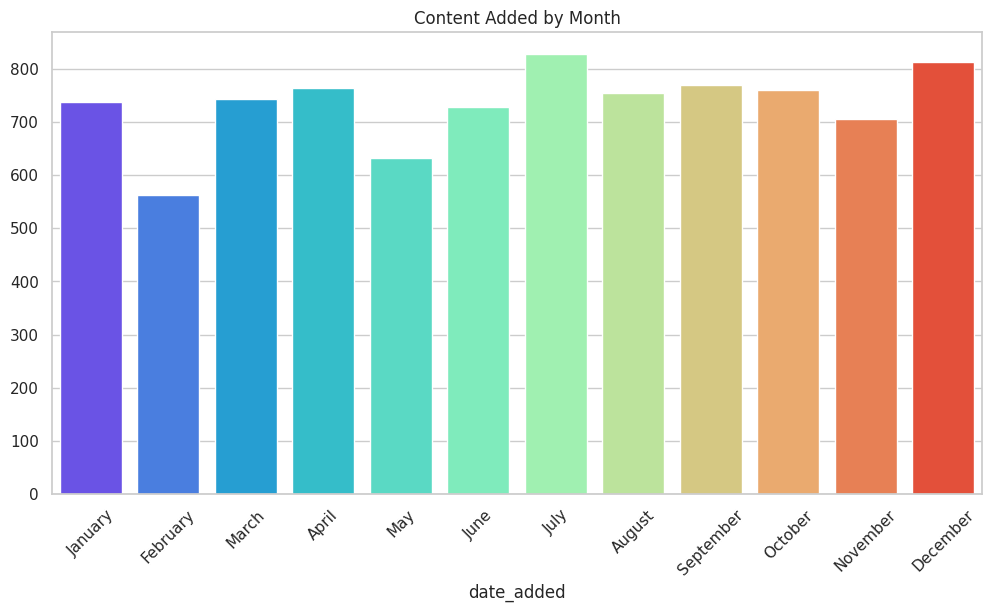

In [15]:
# ==========================================================
# Month Added
# ==========================================================

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

month = (
    df["date_added"]
      .dt.month_name()
      .value_counts()
      .reindex(month_order)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=month.index,
    y=month.values,
    palette="rainbow"
)

plt.xticks(rotation=45)
plt.title("Content Added by Month")

plt.show()

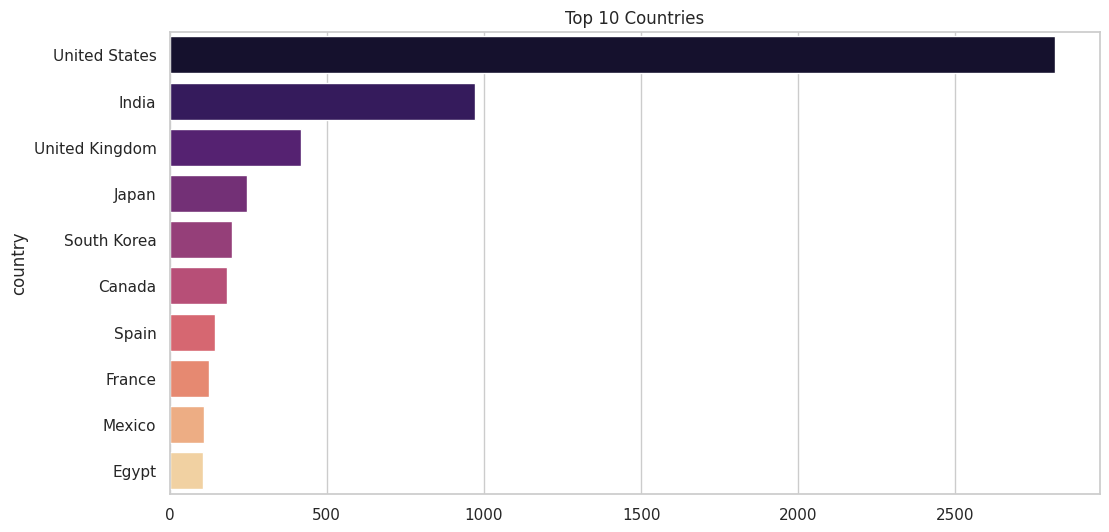

In [16]:
top_country = (
    df["country"]
      .dropna()
      .value_counts()
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    palette="magma"
)

plt.title("Top 10 Countries")

plt.show()

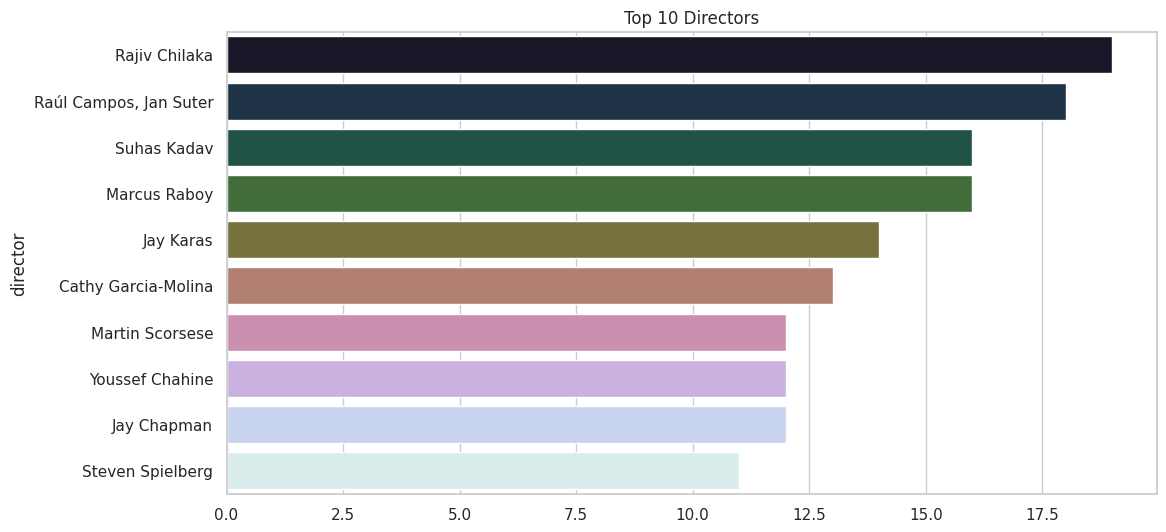

In [17]:
top_director = (
    df["director"]
      .dropna()
      .value_counts()
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_director.values,
    y=top_director.index,
    palette="cubehelix"
)

plt.title("Top 10 Directors")

plt.show()

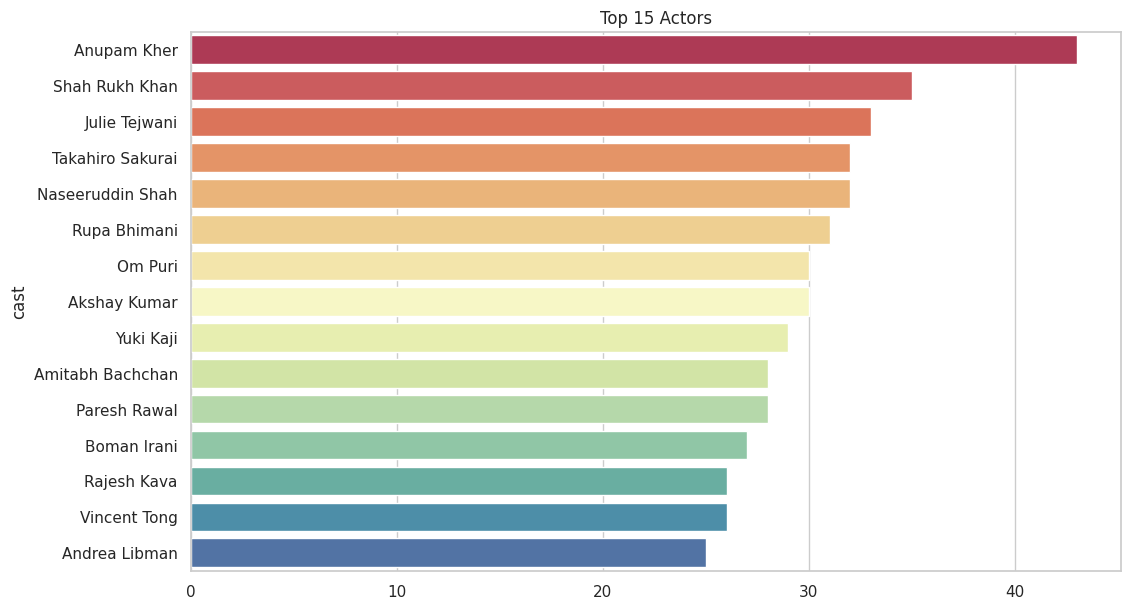

In [18]:
actors = (
    df["cast"]
      .dropna()
      .str.split(",")
      .explode()
      .str.strip()
)

top_actor = actors.value_counts().head(15)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_actor.values,
    y=top_actor.index,
    palette="Spectral"
)

plt.title("Top 15 Actors")

plt.show()

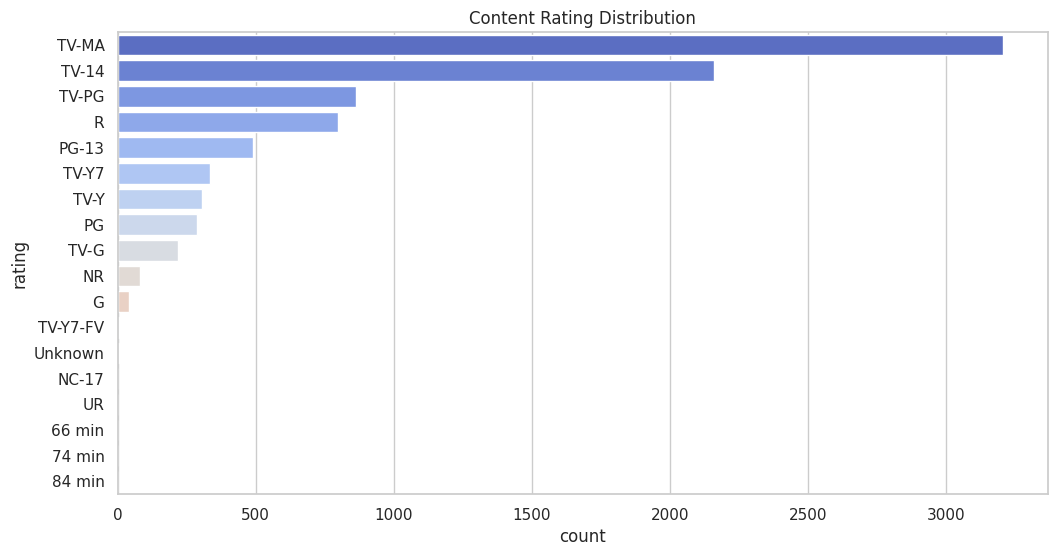

In [19]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df["rating"].fillna("Unknown"),
    order=df["rating"].fillna("Unknown").value_counts().index,
    palette="coolwarm"
)

plt.title("Content Rating Distribution")

plt.show()

## Feature engieering

In [20]:
# Inspect missing values
missing_values = df.isnull().sum()
print('Missing values by column:')
print(missing_values)

# Convert 'date_added' to datetime. This column originally is a string. 
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Derive a new feature from 'date_added': extract year
df['date_added_year'] = df['date_added'].dt.year

# Clean 'duration': transform it into a numeric value
def extract_duration(val):
    if pd.isnull(val):
        return np.nan
    # For Movies: e.g., '90 min', extract minutes. For TV Shows: e.g., '1 Season' or '2 Seasons', extract season count.
    if 'min' in val:
        try:
            return int(val.split(' ')[0])
        except Exception as e:
            return np.nan
    elif 'Season' in val:
        try:
            return int(val.split(' ')[0])
        except Exception as e:
            return np.nan
    else:
        return np.nan

df['duration_numeric'] = df['duration'].apply(extract_duration)

# Display info after cleaning
df.info()

Missing values by column:
show_id              0
type                 0
title                0
director          2634
cast               825
country            831
date_added          10
release_year         0
rating               4
duration             3
listed_in            0
description          0
movie_duration    2679
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   object        
 1   type              8807 non-null   object        
 2   title             8807 non-null   object        
 3   director          6173 non-null   object        
 4   cast              7982 non-null   object        
 5   country           7976 non-null   object        
 6   date_added        8797 non-null   datetime64[ns]
 7   release_year      8807 non-null   int64         
 8   rating    

Prediction Accuracy: 1.00


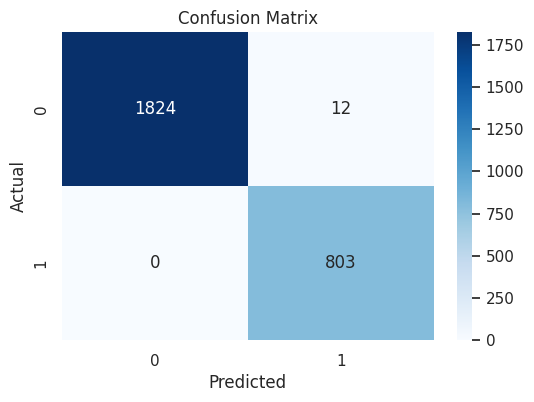

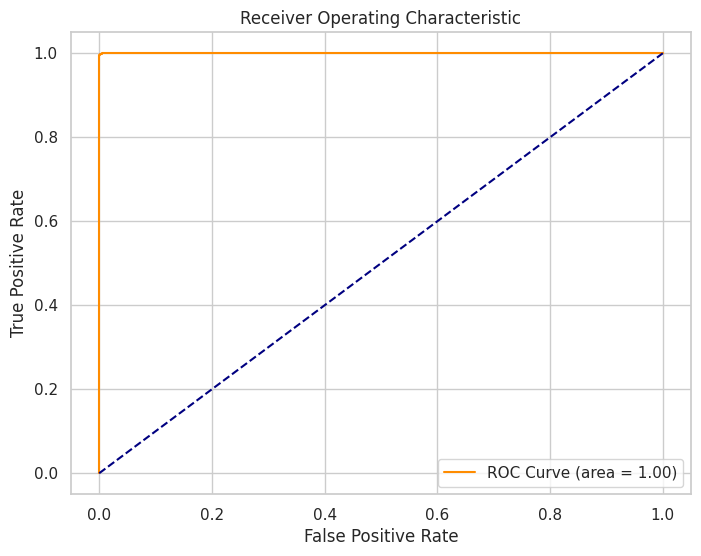

In [21]:
# Prepare data for prediction
# We will use 'release_year', 'date_added_year', and 'duration_numeric' as predictors.
predictor_features = ['release_year', 'date_added_year', 'duration_numeric']
df_pred = df[predictor_features + ['type']].dropna()

# Encode target variable: Movie as 0, TV Show as 1
df_pred['type_encoded'] = df_pred['type'].map({'Movie': 0, 'TV Show': 1})

X = df_pred[predictor_features]
y = df_pred['type_encoded']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f'Prediction Accuracy: {accuracy:.2f}')

# Confusion Matrix Visualization using seaborn heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## Thank you..pls upvote!!!!!!!!!!